# **YOLO - Detección y seguimiento de muñeca mediante distancias**
Pasos a seguir:
1. Detectar una muñeca con YOLO.
2. Realizar el seguimiento de la muñeca seleccionada mediante distancias.

Para llevar a cabo esta tarea, seleccionamos la primera muñeca izquierda (`ID=10`) detectada con YOLO. 

Utilizamos la variable `punto_base` para almacenar el punto de partida de cada frame y la variable `history_dist` para almacenar las distancias de las muñecas detectadas durante la reproducción del vídeo. Luego, si no se ha detectado ninguna muñeca aún, se almacena en `punto_base` la primera muñeca detectada. Seguidamente, se guardan las distancias entre los puntos detectados con YOLO y el punto de referencia. 

Una vez recorridos todos los puntos detectados, se ordenan las distancias de dichos puntos y se escoge el mejor resultado: el punto con la menor distancia. Luego, si aún no hay resultados o la máxima distancia es nula, se añade el resultado obtenido. En caso contrario, se comprueba primero que la distancia al punto base del nuevo resultado sea, como mucho, 1.8 veces la máxima distancia encontrada.

In [5]:
import torch
import cv2
import numpy as np
import math
from ultralytics import YOLO

# Model
model = YOLO('yolo11x-pose.pt')
#model=YOLO('yolov8n-pose.pt') más rápido
# Images
video = cv2.VideoCapture("videos/people2.mp4")

success, frame = video.read()
size=(frame.shape[1], frame.shape[0])
fourcc = cv2.VideoWriter_fourcc(*'DIVX')
video_out = cv2.VideoWriter('output/yolo_pose.mp4', fourcc, 30.0, size)

# Variable para guardar el punto base
punto_base = None
# Variable para guardar el historial de las distancias entre los puntos nuevos y el punto de referencia
history_dist = []

# Bucle a través de los fotogramas del video
while (success):
    puntos =[]
    dist_ptos = [] # Variable para guardar las distancias de todos los puntos detectados en un frame
   
    # Ejecutar seguimiento YOLOv8 en el fotograma, persistiendo los rastreos entre fotogramas
    results = model.track(frame)[0]

    for r in results:
        kpts = r.keypoints
        nk = kpts.shape[1]
        for i in range(nk):
            if i==9: # muñeca izquierda
            # if i==10 # muñeca derecha
                keypoint=kpts.xy[0,i]    
                x, y = (int(keypoint[0])),(int(keypoint[1]))
                
    ####
    # Este código es de invención propia
    ####
                # Si aún no hay punto de referencia, coge el primero que detecta YOLO
                if punto_base is None:
                    punto_base = keypoint
                    cv2.circle(frame, (x,y),5,(0,0,255),-1)
                # Calcula la distancia entre el punto de referencia y el punto detectado
                dist_temp = math.dist(punto_base, keypoint) # función buscada en Google
                # Se guarda la distancia en la lista
                dist_ptos.append((keypoint, dist_temp))
    # Se escoge el punto con menor distancia
    mejor = sorted(dist_ptos, key= lambda x: x[1])[0]

    if len(history_dist) != 0 and sum(history_dist) != 0:
        print(f"Distancia del mejor resultado: {mejor[1]}") # 
        print(f"Valor máximo de las distancias del historial: {max(history_dist)}")
        # Si la distancia es, como mucho, 1.8 veces la mayor distancia de las distancias del historial
        # se toma como punto bueno
        if mejor[1] < max(history_dist) * 1.8:
            punto_base = mejor[0]
            history_dist.append(mejor[1])
            cv2.circle(frame, ((int(mejor[0][0])),(int(mejor[0][1]))),5,(0,0,255),-1)
    else: 
        # Añadir primer punto o puntos con distancia=0
        punto_base = mejor[0]
        history_dist.append(mejor[1])
        cv2.circle(frame, ((int(mejor[0][0])),(int(mejor[0][1]))),5,(0,0,255),-1)
    ####
    
    # Mostrar el fotograma anotado
    cv2.imshow('salida',frame)
    video_out.write(frame)
    success, frame = video.read()
    # Romper el bucle si se presiona 'q'
    if cv2.waitKey(1) & 0xFF == ord("q"):
         success = False
         break
    

# Liberar el objeto de captura de video y cerrar la ventana de visualización
video.release()
video_out.release()
cv2.destroyAllWindows()


0: 384x640 7 persons, 626.4ms
Speed: 1.6ms preprocess, 626.4ms inference, 2.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 7 persons, 659.6ms
Speed: 2.5ms preprocess, 659.6ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 7 persons, 628.4ms
Speed: 1.6ms preprocess, 628.4ms inference, 2.9ms postprocess per image at shape (1, 3, 384, 640)
Distancia del mejor resultado: 4.055956633853918
Valor máximo de las distancias del historial: 6.347801562553343

0: 384x640 8 persons, 632.8ms
Speed: 1.6ms preprocess, 632.8ms inference, 3.1ms postprocess per image at shape (1, 3, 384, 640)
Distancia del mejor resultado: 3.5157097024780417
Valor máximo de las distancias del historial: 6.347801562553343

0: 384x640 8 persons, 681.9ms
Speed: 1.8ms preprocess, 681.9ms inference, 3.1ms postprocess per image at shape (1, 3, 384, 640)
Distancia del mejor resultado: 5.743177419195161
Valor máximo de las distancias del historial: 6.347801562553343

0: 384x640 8 p

TODO:
- Gráficas:
    - coordenada x vs tiempo (1/freq)
    - coordenada y vs tiempo (1/freq)

In [33]:
import torch
import cv2
import numpy as np
import math
from ultralytics import YOLO

# Model
model = YOLO('yolo11x-pose.pt')
#model=YOLO('yolov8n-pose.pt') más rápido
# Images
video = cv2.VideoCapture("videos/people2.mp4")

success, frame = video.read()
size=(frame.shape[1], frame.shape[0])
fourcc = cv2.VideoWriter_fourcc(*'DIVX')
video_out = cv2.VideoWriter('output/yolo_pose.mp4', fourcc, 30.0, size)

# Variable para guardar el punto base
punto_base = None
# Variable para guardar el historial de las distancias entre los puntos nuevos y el punto de referencia
history_dist = []
# Variable para guardar el historial de puntos detectados
history_points = []

# Bucle a través de los fotogramas del video
while (success):
    puntos =[]
    dist_ptos = [] # Variable para guardar las distancias de todos los puntos detectados en un frame
   
    # Ejecutar seguimiento YOLOv8 en el fotograma, persistiendo los rastreos entre fotogramas
    results = model.track(frame)[0]

    for r in results:
        kpts = r.keypoints
        nk = kpts.shape[1]
        for i in range(nk):
            if i==10: # muñeca derecha
                keypoint=kpts.xy[0,i]    
                x, y = (int(keypoint[0])),(int(keypoint[1]))
                
    ####
    # Este código es de invención propia
    ####
                # Si aún no hay punto de referencia, coge el primero que detecta YOLO
                if punto_base is None:
                    punto_base = keypoint
                    cv2.circle(frame, (x,y),5,(0,0,255),-1)
                # Calcula la distancia entre el punto de referencia y el punto detectado
                dist_temp = math.dist(punto_base, keypoint) # función buscada en Google
                # Se guarda la distancia en la lista
                dist_ptos.append((keypoint, dist_temp))
    # Se escoge el punto con menor distancia
    mejor = sorted(dist_ptos, key= lambda x: x[1])[0]

    if len(history_dist) != 0 and sum(history_dist) != 0:
        print(f"Distancia del mejor resultado: {mejor[1]}") # 
        print(f"Valor máximo de las distancias del historial: {max(history_dist)}")
        # Si la distancia es, como mucho, 1.8 veces la mayor distancia de las distancias del historial
        # se toma como punto bueno
        if mejor[1] < max(history_dist) * 1.8:
            punto_base = mejor[0]
            history_points.append(punto_base)
            history_dist.append(mejor[1])
            cv2.circle(frame, ((int(mejor[0][0])),(int(mejor[0][1]))),5,(0,0,255),-1)
        else:
            # No se detecta, por tanto, ponemos a (0,0)
            history_points.append((0,0))
    else: 
        # Añadir primer punto o puntos con distancia=0
        punto_base = mejor[0]
        history_points.append(punto_base)
        history_dist.append(mejor[1])
        cv2.circle(frame, ((int(mejor[0][0])),(int(mejor[0][1]))),5,(0,0,255),-1)
    
    # Guardar los puntos detectados en el historial para graficar
    
    ####
    
    # Mostrar el fotograma anotado
    cv2.imshow('salida',frame)
    video_out.write(frame)
    success, frame = video.read()
    # Romper el bucle si se presiona 'q'
    if cv2.waitKey(1) & 0xFF == ord("q"):
         success = False
         break
    

# Liberar el objeto de captura de video y cerrar la ventana de visualización
video.release()
video_out.release()
cv2.destroyAllWindows()


0: 384x640 7 persons, 806.4ms
Speed: 5.2ms preprocess, 806.4ms inference, 2.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 7 persons, 669.8ms
Speed: 2.6ms preprocess, 669.8ms inference, 3.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 7 persons, 643.7ms
Speed: 1.6ms preprocess, 643.7ms inference, 3.1ms postprocess per image at shape (1, 3, 384, 640)
Distancia del mejor resultado: 4.844507035962502
Valor máximo de las distancias del historial: 10.627427601208298

0: 384x640 8 persons, 641.4ms
Speed: 1.5ms preprocess, 641.4ms inference, 3.6ms postprocess per image at shape (1, 3, 384, 640)
Distancia del mejor resultado: 4.547948553747901
Valor máximo de las distancias del historial: 10.627427601208298

0: 384x640 8 persons, 709.4ms
Speed: 1.6ms preprocess, 709.4ms inference, 2.4ms postprocess per image at shape (1, 3, 384, 640)
Distancia del mejor resultado: 5.811115020736512
Valor máximo de las distancias del historial: 10.627427601208298

0: 384x640 8

Graficamos las coordenadas con respecto al tiempo (medido en frames)

Función propia para graficar

341
2
[tensor([488.2166, 493.6873]), tensor([490.3948, 483.2854]), tensor([490.0004, 478.4570]), tensor([490.7947, 473.9789]), tensor([490.7278, 468.1682]), tensor([491.3172, 464.5961]), tensor([491.4197, 461.5056]), tensor([489.9106, 455.7197]), tensor([489.6846, 452.0661]), tensor([488.2318, 450.5838]), tensor([487.6921, 447.8556]), tensor([488.0892, 443.3136]), tensor([488.1735, 438.9209]), tensor([488.5792, 438.9088]), tensor([487.2959, 435.5433]), tensor([488.3607, 431.9409]), tensor([489.2312, 427.7467]), tensor([487.6961, 425.1151]), tensor([488.5052, 420.9586]), tensor([488.2238, 419.3628]), tensor([487.6223, 416.9591]), tensor([487.8101, 415.7099]), tensor([488.3438, 415.4161]), tensor([488.2245, 413.5230]), tensor([488.4329, 410.2712]), tensor([488.9388, 407.5186]), tensor([489.2160, 404.7803]), tensor([489.8750, 398.0452]), tensor([489.9217, 394.0539]), tensor([489.1986, 391.1419]), tensor([489.4177, 387.0224]), tensor([489.3957, 384.1651]), tensor([489.4450, 376.3548]), ten

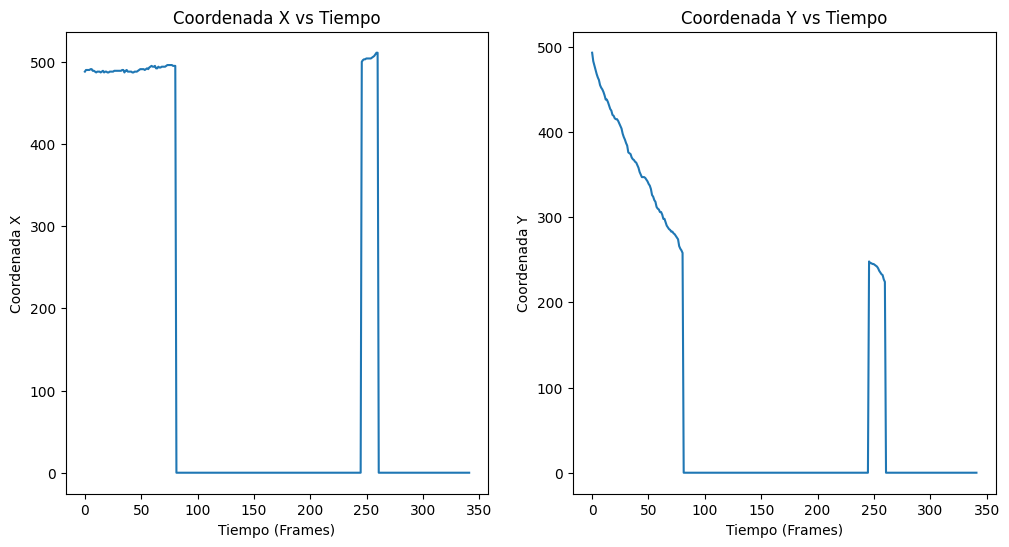

In [34]:
import matplotlib.pyplot as plt
t = np.linspace(0, len(history_points), num=len(history_points))
print(len(t))
print(len(history_points[0]))

print(history_points)
x_points = []
y_points = []
for point in history_points:
    x_points.append(int(point[0]))
    y_points.append(int(point[1]))

print(len(history_points))
plt.figure(1, (12,6))
plt.subplot(1,2,1)
plt.plot(t, x_points)
plt.ylabel("Coordenada X")
plt.xlabel("Tiempo (Frames)")
plt.title("Coordenada X vs Tiempo")
plt.subplot(1,2,2)
plt.plot(t, y_points)
plt.ylabel("Coordenada Y")
plt.xlabel("Tiempo (Frames)")
plt.title("Coordenada Y vs Tiempo")
plt.show()
    

En la gráfica se observa que tras varios frames sin detección, vuelve a detectar una muñeca. Sin embargo, si observamos el vídeo, vemos que una persona distinta pasa después de un tiempo por el mismo sitio donde se quedó la última detección de la muñeca.